# Airline Delay Analysis

#### This coursework uses the U.S. Department of Transportation’s Airline On-Time Statistics and Delay Causes dataset, which provides monthly records on domestic flights operated by major U.S. carriers. The dataset includes counts of on-time, delayed, canceled, and diverted flights, along with detailed delay-cause categories such as Air Carrier, Extreme Weather, NAS (National Aviation System), Late-Arriving Aircraft, and Security.

#### Using this dataset of over 400,000 flight records (2003-2025), the coursework develops a full machine learning pipeline for analyzing and predicting airline delays. The goal is to perform exploratory data analysis, engineer meaningful features, train regression and classification models, and deploy an interactive Streamlit application for real-time delay predictions. The project also aims to extract business insights that airlines and airports can use to improve operational efficiency and reduce delays.





# Loading the dataset, identify shape and overview

In [604]:
import pandas as pd

df = pd.read_csv('data/Airline_Delay_Cause.csv')
print("Dataset loaded sucessfully!!!")

print(f"Dataset shape: {df.shape}")


Dataset loaded sucessfully!!!
Dataset shape: (409612, 21)


# Exploratory Data Analysis (EDA)

In [605]:
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
print("=" * 40)
print("Dataset First 10 rows: ")
df.head(10)


Dataset shape: 409612 rows x 21 columns
Dataset First 10 rows: 


,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2025,7,YV,Mesa Airlines Inc.,BWI,"Baltimore, MD: Baltimore/Washington Internatio...",18.0,2.0,1.43,0.00,...,0.0,0.00,0.0,0.0,44.0,32.0,0.0,12.0,0.0,0.0
1,2025,7,YV,Mesa Airlines Inc.,CHS,"Charleston, SC: Charleston AFB/International",48.0,16.0,4.06,3.15,...,0.0,3.30,2.0,0.0,1282.0,331.0,438.0,259.0,0.0,254.0
2,2025,7,YV,Mesa Airlines Inc.,CLE,"Cleveland, OH: Cleveland-Hopkins International",65.0,10.0,3.53,1.00,...,0.0,2.43,2.0,0.0,735.0,151.0,172.0,139.0,0.0,273.0
3,2025,7,YV,Mesa Airlines Inc.,CLT,"Charlotte, NC: Charlotte Douglas International",134.0,31.0,13.19,2.43,...,0.0,4.74,8.0,0.0,2264.0,798.0,303.0,702.0,0.0,461.0
4,2025,7,YV,Mesa Airlines Inc.,CMH,"Columbus, OH: John Glenn Columbus International",61.0,12.0,6.44,0.28,...,0.0,1.69,0.0,0.0,630.0,211.0,17.0,123.0,0.0,279.0
5,2025,7,YV,Mesa Airlines Inc.,COS,"Colorado Springs, CO: City of Colorado Springs...",31.0,5.0,1.84,0.00,...,0.0,2.01,0.0,0.0,668.0,154.0,0.0,67.0,0.0,447.0
6,2025,7,YV,Mesa Airlines Inc.,CRP,"Corpus Christi, TX: Corpus Christi International",19.0,4.0,0.71,0.30,...,0.0,2.29,1.0,0.0,823.0,45.0,6.0,14.0,0.0,758.0
7,2025,7,YV,Mesa Airlines Inc.,CVG,"Cincinnati, OH: Cincinnati/Northern Kentucky I...",75.0,14.0,7.64,1.00,...,0.0,1.79,0.0,0.0,722.0,485.0,24.0,81.0,0.0,132.0
8,2025,7,YV,Mesa Airlines Inc.,DFW,"Dallas/Fort Worth, TX: Dallas/Fort Worth Inter...",97.0,23.0,8.09,0.73,...,0.0,9.33,1.0,0.0,2125.0,655.0,65.0,437.0,0.0,968.0
9,2025,7,YV,Mesa Airlines Inc.,DRO,"Durango, CO: Durango La Plata County",31.0,1.0,0.82,0.00,...,0.0,0.00,0.0,0.0,50.0,41.0,0.0,9.0,0.0,0.0


In [606]:
print('Checking datatypes: ')
df.info()
print("=" * 40)

Checking datatypes: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 409612 entries, 0 to 409611
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 409612 non-null  int64  
 1   month                409612 non-null  int64  
 2   carrier              409612 non-null  object 
 3   carrier_name         409612 non-null  object 
 4   airport              409612 non-null  object 
 5   airport_name         409612 non-null  object 
 6   arr_flights          408952 non-null  float64
 7   arr_del15            408656 non-null  float64
 8   carrier_ct           408952 non-null  float64
 9   weather_ct           408952 non-null  float64
 10  nas_ct               408952 non-null  float64
 11  security_ct          408952 non-null  float64
 12  late_aircraft_ct     408952 non-null  float64
 13  arr_cancelled        408952 non-null  float64
 14  arr_diverted         408952 non-null  float64
 

In [607]:
print('Summary for numerical columns:')
df.describe()

Summary for numerical columns:


,year,month,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
count,409612.000000,409612.000000,408952.000000,408656.000000,408952.000000,408952.000000,408952.000000,408952.000000,408952.000000,408952.000000,408952.000000,408952.000000,408952.000000,408952.000000,408952.000000,408952.000000,408952.000000
mean,2014.715218,6.468014,361.155219,69.864434,20.621496,2.536097,22.230743,0.171458,24.254104,6.744285,0.840910,4218.975002,1324.919900,228.574708,1034.045357,7.148976,1624.278981
std,6.616430,3.442544,993.827182,194.585817,48.715269,9.662785,79.393254,0.821340,74.913717,34.782892,3.834991,12976.256753,3905.756663,909.755462,4362.757658,39.156889,5246.925768
min,2003.000000,1.000000,1.000000,0.000000,0.000000,0.000000,-0.010000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-19.000000,0.000000,0.000000
25%,2009.000000,3.000000,55.000000,8.000000,2.790000,0.000000,1.410000,0.000000,1.540000,0.000000,0.000000,408.000000,134.000000,0.000000,49.000000,0.000000,77.000000
50%,2015.000000,6.000000,112.000000,21.000000,7.500000,0.530000,4.910000,0.000000,5.550000,1.000000,0.000000,1150.000000,411.000000,23.000000,184.000000,0.000000,347.000000
75%,2021.000000,9.000000,254.000000,52.000000,18.660000,2.000000,13.980000,0.000000,16.270000,4.000000,1.000000,2999.000000,1082.000000,158.000000,558.000000,0.000000,1104.000000
max,2025.000000,12.000000,21977.000000,6377.000000,1886.580000,717.940000,4091.270000,80.560000,2588.130000,4951.000000,256.000000,648300.000000,321792.000000,64550.000000,238440.000000,3760.000000,279153.000000


In [608]:
print('Summary for categorical columns:')
df.describe(include=['object'])

Summary for categorical columns:


,carrier,carrier_name,airport,airport_name
count,409612,409612,409612,409612
unique,38,51,426,460
top,OO,SkyWest Airlines Inc.,DTW,"Detroit, MI: Detroit Metro Wayne County"
freq,47650,47650,3785,3785


In [609]:
print('Checking missing values:')
df.isnull().sum()


Checking missing values:


year                     0
month                    0
carrier                  0
carrier_name             0
airport                  0
airport_name             0
arr_flights            660
arr_del15              956
carrier_ct             660
weather_ct             660
nas_ct                 660
security_ct            660
late_aircraft_ct       660
arr_cancelled          660
arr_diverted           660
arr_delay              660
carrier_delay          660
weather_delay          660
nas_delay              660
security_delay         660
late_aircraft_delay    660
dtype: int64

In [610]:
print('Checking for duplicates:')
df.duplicated().sum()

Checking for duplicates:


0

### Distribution of arrival delay

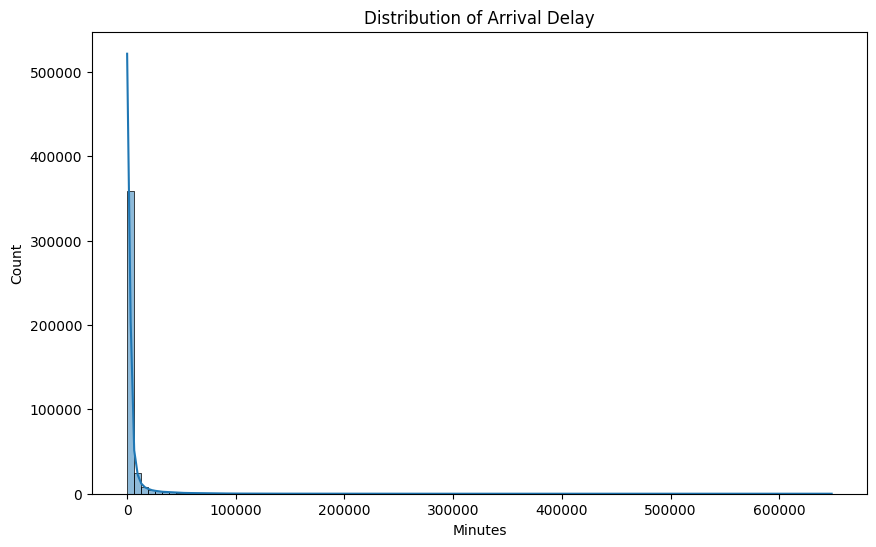

In [611]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.histplot(df['arr_delay'], bins=100, kde=True)
plt.title('Distribution of Arrival Delay')
plt.xlabel('Minutes')
plt.ylabel('Count')
plt.show()

### Correlation Matrix

In [612]:
import numpy as np

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(12, 10))
correlation_matrix = df[num_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()


#### Avarage delay by type(cause of delay)

In [613]:
delay_types = ['carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']
delay_means = df[delay_types].mean()
plt.bar(delay_means.index, delay_means.values)
plt.title('Average Delay by Type')
plt.xlabel('Delay Type')
plt.ylabel('Average Minutes')
plt.xticks(rotation=45)
plt.show()



#### Delays by carier

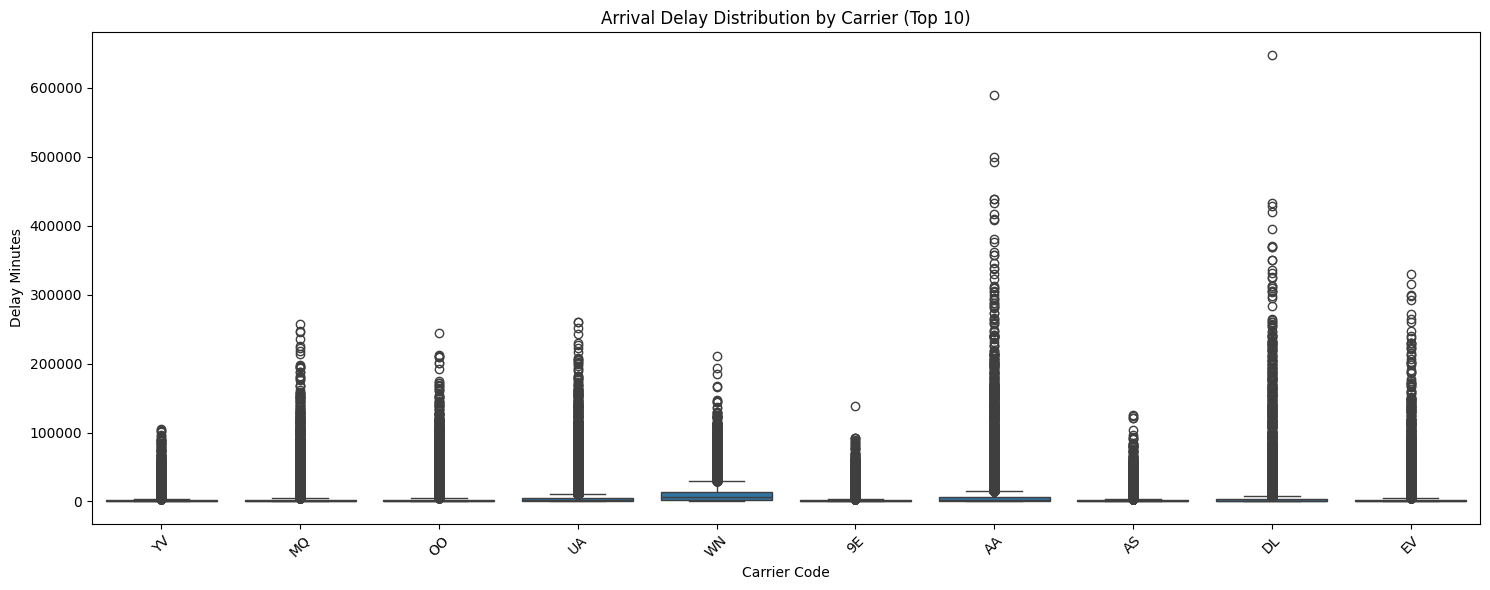

In [614]:
plt.figure(figsize=(15, 6))
top_carriers = df['carrier'].value_counts().nlargest(10).index
df_top = df[df['carrier'].isin(top_carriers)]
sns.boxplot(x='carrier', y='arr_delay', data=df_top)
plt.title('Arrival Delay Distribution by Carrier (Top 10)')
plt.xlabel('Carrier Code')
plt.ylabel('Delay Minutes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Avarage Delay by Month

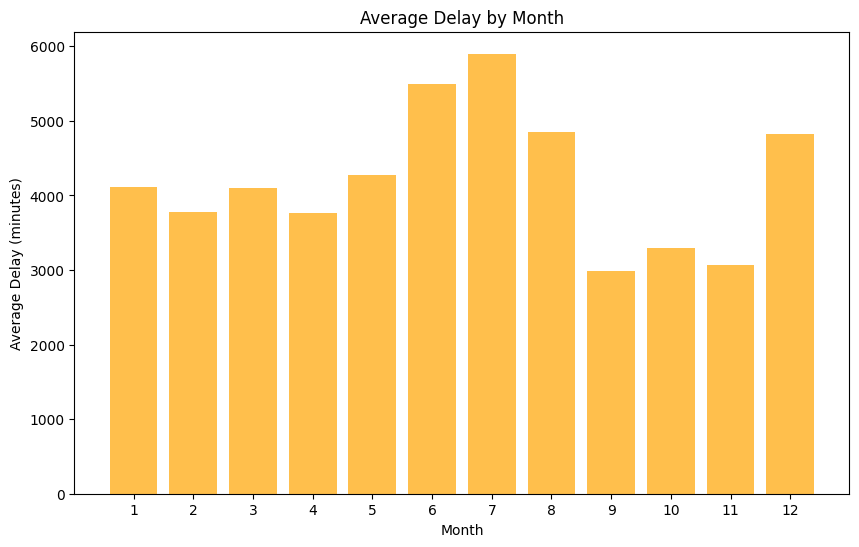

In [615]:
monthly_delay = df.groupby('month')['arr_delay'].mean()

plt.figure(figsize=(10, 6))
plt.bar(monthly_delay.index, monthly_delay.values, color='orange', alpha=0.7)
plt.title('Average Delay by Month')
plt.xlabel('Month')
plt.ylabel('Average Delay (minutes)')
plt.xticks(range(1, 13))
plt.show()

#### Cancellation and diversion graphs

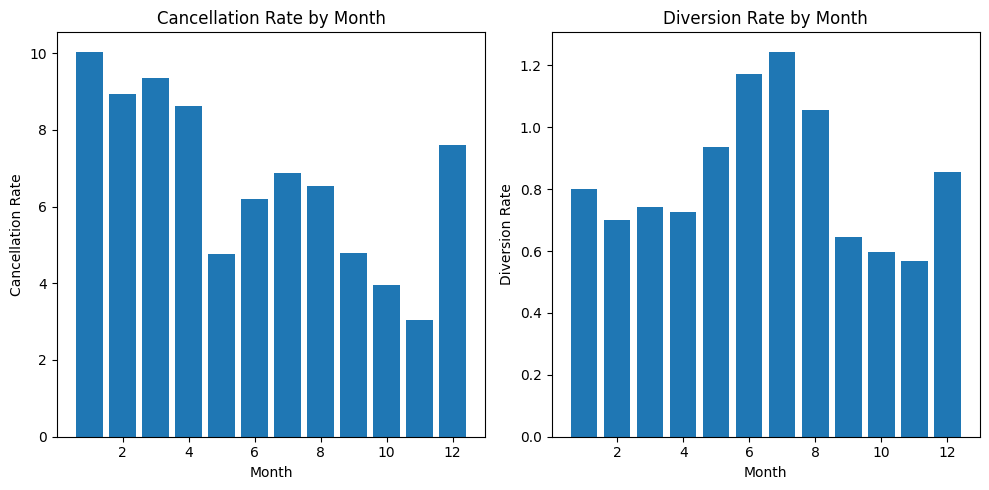

In [616]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
cancellation_rate = df.groupby('month')['arr_cancelled'].mean()
plt.bar(cancellation_rate.index, cancellation_rate.values)
plt.title('Cancellation Rate by Month')
plt.xlabel('Month')
plt.ylabel('Cancellation Rate')

plt.subplot(1, 2, 2)
diversion_rate = df.groupby('month')['arr_diverted'].mean()
plt.bar(diversion_rate.index, diversion_rate.values)
plt.title('Diversion Rate by Month')
plt.xlabel('Month')
plt.ylabel('Diversion Rate')

plt.tight_layout()
plt.show()

# Data Preperation 


### Copy of dataset for preprocessing

In [617]:
df_clean = df.copy()

### Handling Missing Values

In [618]:
print(f"Missing values before handling:")
print(df_clean.isnull().sum().sort_values(ascending=False))

Missing values before handling:
arr_del15              956
nas_ct                 660
security_ct            660
security_delay         660
nas_delay              660
weather_delay          660
carrier_delay          660
arr_delay              660
arr_diverted           660
arr_cancelled          660
late_aircraft_ct       660
late_aircraft_delay    660
weather_ct             660
carrier_ct             660
arr_flights            660
month                    0
airport_name             0
airport                  0
carrier_name             0
carrier                  0
year                     0
dtype: int64


For better performance of the upcoming models i have chosen filling missing values rather than dropping them, and followed strategy below:
- for delay minutes columns filling with 0(no delays)
- for categorical columns filled with 'Unknown'

In [619]:
delay_minutes_cols = ['carrier_delay', 'weather_delay', 'nas_delay', 
                      'security_delay', 'late_aircraft_delay', 'arr_delay', 'arr_cancelled', 'arr_diverted']
for col in delay_minutes_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(0)
        
print('Data filled with 0 for delay minutes columns')        

Data filled with 0 for delay minutes columns


In [620]:
count_cols = ['carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 
              'late_aircraft_ct', 'arr_del15', 'arr_flights']
for col in count_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(0)
        
print('Data filled with 0 for count columns')        

Data filled with 0 for count columns


In [621]:
categorical_cols = ['carrier', 'carrier_name', 'airport', 'airport_name']
for col in categorical_cols:
    if col in df_clean.columns and df_clean[col].isnull().any():
        df_clean[col] = df_clean[col].fillna('Unknown')
        
print('Data filled with Unknown for categorical columns')        

Data filled with Unknown for categorical columns


In [622]:
print(f"\nMissing values after handling:")
print(df_clean.isnull().sum().sort_values(ascending=False))


Missing values after handling:
year                   0
security_ct            0
security_delay         0
nas_delay              0
weather_delay          0
carrier_delay          0
arr_delay              0
arr_diverted           0
arr_cancelled          0
late_aircraft_ct       0
nas_ct                 0
month                  0
weather_ct             0
carrier_ct             0
arr_del15              0
arr_flights            0
airport_name           0
airport                0
carrier_name           0
carrier                0
late_aircraft_delay    0
dtype: int64


### Checking for data with errors (eg. negative flights, delays more than flights )

In [623]:
if 'arr_flights' in df_clean.columns:
    negative_flights = (df_clean['arr_flights'] < 0).sum()
    if negative_flights > 0:
        print(f"Found {negative_flights} rows with negative flight count. Setting to 0.")
        df_clean['arr_flights'] = df_clean['arr_flights'].clip(lower=0)

In [624]:
if all(col in df_clean.columns for col in ['arr_del15', 'arr_flights']):
    impossible = (df_clean['arr_del15'] > df_clean['arr_flights']).sum()
    if impossible > 0:
        print(f"Found {impossible} rows where delayed flights > total flights. Correcting...")
        df_clean['arr_del15'] = df_clean[['arr_del15', 'arr_flights']].min(axis=1)

### Outliers

In [625]:
def handle_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = ((data[column] < lower_bound) | (data[column] > upper_bound)).sum()
    
    if outliers > 0:
        data[column] = np.clip(data[column], lower_bound, upper_bound)
    
    return outliers

outlier_cols = ['arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay', 'late_aircraft_delay']

for col in outlier_cols:
    if col in df_clean.columns:
        outliers_count = handle_outliers(df_clean, col)
        if outliers_count > 0:
            print(f"  - {col}: {outliers_count} outliers capped")

print("Outliers handled using IQR method!!!")

  - arr_delay: 46990 outliers capped
  - carrier_delay: 43030 outliers capped
  - weather_delay: 51053 outliers capped
  - nas_delay: 50811 outliers capped
  - late_aircraft_delay: 48270 outliers capped
Outliers handled using IQR method!!!


# Feature Engineering

New binary target for classifying whether there is delay or not

In [626]:
df_clean['delay_rate'] = df_clean['arr_del15'] / df_clean['arr_flights'].replace(0, 1)
print("Delay rate statistics:")
print(df_clean['delay_rate'].describe())

df_clean['high_delay_month'] = (df_clean['delay_rate'] > 0.25).astype(int)
print("Class distribution:")
print(df_clean['high_delay_month'].value_counts(normalize=True) * 100)

delay_cause_cols = ['carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']
total_delay_minutes = df_clean[delay_cause_cols].sum(axis=1)

for col in delay_cause_cols:
    percentage_col = col.replace('_delay', '_percentage')
    df_clean[percentage_col] = np.where(
        total_delay_minutes > 0,
        df_clean[col] / total_delay_minutes * 100,
        0
    )

Delay rate statistics:
count    409612.000000
mean          0.198698
std           0.115119
min           0.000000
25%           0.122642
50%           0.185930
75%           0.258621
max           1.000000
Name: delay_rate, dtype: float64
Class distribution:
high_delay_month
0    72.928772
1    27.071228
Name: proportion, dtype: float64


In [627]:
df_clean['quarter'] = ((df_clean['month'] - 1) // 3) + 1
df_clean['is_winter'] = df_clean['month'].isin([12, 1, 2]).astype(int)
df_clean['is_summer'] = df_clean['month'].isin([6, 7, 8]).astype(int)
df_clean['is_peak_travel'] = df_clean['month'].isin([6, 7, 8, 11, 12]).astype(int)


In [628]:
df_clean['flights_per_day'] = df_clean['arr_flights'] / 30  # Approximate daily flights
df_clean['cancellation_rate'] = df_clean['arr_cancelled'] / df_clean['arr_flights'].replace(0, 1)
df_clean['total_disruptions'] = df_clean['arr_cancelled'] + df_clean['arr_diverted']

In [629]:
airport_stats = df_clean.groupby('airport').agg({
    'arr_flights': ['sum', 'mean'],  # Use flight volume, not delay rate
    'arr_cancelled': 'sum',
    'arr_diverted': 'sum'
}).round(2)

# Flatten column names
airport_stats.columns = ['airport_total_flights', 'airport_avg_flights', 'airport_total_cancelled', 'airport_total_diverted']

carrier_stats = df_clean.groupby('carrier').agg({
    'arr_flights': ['sum', 'mean'],  # Use flight volume, not delay rate
    'arr_cancelled': 'sum', 
    'arr_diverted': 'sum'
}).round(2)

# Flatten column names  
carrier_stats.columns = ['carrier_total_flights', 'carrier_avg_flights', 'carrier_total_cancelled', 'carrier_total_diverted']

# Merge back
df_clean = df_clean.merge(airport_stats, left_on='airport', right_index=True, how='left')
df_clean = df_clean.merge(carrier_stats, left_on='carrier', right_index=True, how='left')

print("Feature engineering completed without data leakage!")
print(f"Dataset shape: {df_clean.shape}")

Feature engineering completed without data leakage!
Dataset shape: (409612, 43)


In [630]:
# Remove data leakage columns and redundant features
leakage_cols = [
    # Direct delay indicators (CRITICAL TO REMOVE)
    'arr_del15', 'arr_delay',
    'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay',
    'carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct',
    
    # Target-derived features (CRITICAL TO REMOVE)
    'delay_rate',  # Used to create target
    'carrier_percentage', 'weather_percentage', 'nas_percentage', 'security_percentage', 'late_aircraft_percentage',
    
    # Redundant features
    'carrier_name', 'airport_name'
]

# Keep percentage columns for cause prediction
clean_features = [col for col in df_clean.columns if col not in leakage_cols + ['high_delay_month']]
df_model = df_clean[clean_features + ['high_delay_month']].copy()

print(f"Removed {len(leakage_cols)} leakage columns")
print(f"Clean dataset shape: {df_model.shape}")
print("Remaining features:", clean_features)

Removed 20 leakage columns
Clean dataset shape: (409612, 23)
Remaining features: ['year', 'month', 'carrier', 'airport', 'arr_flights', 'arr_cancelled', 'arr_diverted', 'quarter', 'is_winter', 'is_summer', 'is_peak_travel', 'flights_per_day', 'cancellation_rate', 'total_disruptions', 'airport_total_flights', 'airport_avg_flights', 'airport_total_cancelled', 'airport_total_diverted', 'carrier_total_flights', 'carrier_avg_flights', 'carrier_total_cancelled', 'carrier_total_diverted']


### Feature and Target Prepation

In [631]:
# Prepare features and target
X = df_model.drop('high_delay_month', axis=1)
y = df_model['high_delay_month']

print(f"Features shape: {X.shape}")
print(f"Target distribution:")
print(y.value_counts(normalize=True) * 100)

# Check class imbalance ratio
imbalance_ratio = y.value_counts()
minority_ratio = imbalance_ratio[1] / imbalance_ratio[0]
print(f"Class imbalance ratio: {imbalance_ratio[0]}:{imbalance_ratio[1]} (No delay:Delay)")
print(f"Minority class is {minority_ratio:.2%} of majority class")

Features shape: (409612, 22)
Target distribution:
high_delay_month
0    72.928772
1    27.071228
Name: proportion, dtype: float64
Class imbalance ratio: 298725:110887 (No delay:Delay)
Minority class is 37.12% of majority class


### Class Weight Method for Imbalance handling

In [632]:
# BEST PRACTICE: Proper class weight handling
from sklearn.utils.class_weight import compute_class_weight

# Calculate class weights
classes = np.unique(y)
class_weights = compute_class_weight('balanced', classes=classes, y=y)
class_weight_dict = dict(zip(classes, class_weights))

print(f"Calculated class weights: {class_weight_dict}")
print(f"Minority class weight: {class_weight_dict[1]:.3f}")
print(f"Majority class weight: {class_weight_dict[0]:.3f}")
print(f"Weight ratio: {class_weight_dict[1]/class_weight_dict[0]:.2f}x")

Calculated class weights: {0: 0.6856004686584651, 1: 1.8469793573638027}
Minority class weight: 1.847
Majority class weight: 0.686
Weight ratio: 2.69x


### Encode Categorical Variables

In [633]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
label_encoders = {}

X_encoded = X.copy()
for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))
    label_encoders[col] = le
    print(f"Encoded {col}: {len(le.classes_)} unique values")

print("Categorical encoding completed!")

Encoded carrier: 38 unique values
Encoded airport: 426 unique values
Categorical encoding completed!


### Scaling the features

In [634]:
from sklearn.preprocessing import StandardScaler

# Feature Scaling
scaler = StandardScaler()
numerical_cols = X_encoded.select_dtypes(include=[np.number]).columns
X_scaled = X_encoded.copy()
X_scaled[numerical_cols] = scaler.fit_transform(X_encoded[numerical_cols])

print("Feature scaling completed!")

Feature scaling completed!


### Data Splitting

In [635]:
# BEST PRACTICE: Stratified split to maintain class distribution
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # CRITICAL: Maintain class distribution
)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set: {X_test.shape[0]:,} samples")
print(f"Features: {X_train.shape[1]}")

# Verify stratification worked
print("\nClass distribution verification:")
print("Training set:")
train_dist = pd.Series(y_train).value_counts(normalize=True) * 100
for idx, val in train_dist.items():
    status = "High Delay" if idx == 1 else "No High Delay"
    print(f"  {status}: {val:.2f}%")

print("Test set:")
test_dist = pd.Series(y_test).value_counts(normalize=True) * 100
for idx, val in test_dist.items():
    status = "High Delay" if idx == 1 else "No High Delay"
    print(f"  {status}: {val:.2f}%")

Training set: 327,689 samples
Test set: 81,923 samples
Features: 22

Class distribution verification:
Training set:
  No High Delay: 72.93%
  High Delay: 27.07%
Test set:
  No High Delay: 72.93%
  High Delay: 27.07%


# ML Models - Algorithms training

In [636]:
models = {}
training_times = {}
cv_scores = {}

In [637]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
import time

print("Training Logistic Regression...")

lr_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=2000)

start_time = time.time()
lr_model.fit(X_train, y_train)
lr_time = time.time() - start_time

models['Logistic Regression'] = lr_model
training_times['Logistic Regression'] = lr_time

# Cross-validation score
lr_cv_scores = cross_val_score(lr_model, X_train, y_train, cv=3, scoring='f1', n_jobs=-1)
cv_scores['Logistic Regression'] = lr_cv_scores.mean()

print(f"Training time: {lr_time:.2f} seconds")
print(f"CV F1-score: {lr_cv_scores.mean():.4f} (+/- {lr_cv_scores.std() * 2:.4f})")

Training Logistic Regression...
Training time: 0.54 seconds
CV F1-score: 0.4814 (+/- 0.0041)


In [638]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
import time

print('Training Random Forest...')


rf_model = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

start_time = time.time()

rf_time = time.time() - start_time

models['Random Forest'] = rf_model
training_times['Random Forest'] = rf_time

# Cross-validation score
rf_cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='f1', n_jobs=-1)
cv_scores['Random Forest'] = rf_cv_scores.mean()

print(f"Training time: {rf_time:.2f} seconds")
print(f"CV F1-score: {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std() * 2:.4f})")

Training Random Forest...
Training time: 0.00 seconds
CV F1-score: 0.5363 (+/- 0.0075)


In [639]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance'
)

start_time = time.time()
knn_model.fit(X_train, y_train)
knn_time = time.time() - start_time

models['K-Nearest Neighbors'] = knn_model
training_times['K-Nearest Neighbors'] = knn_time

# Cross-validation score
knn_cv_scores = cross_val_score(knn_model, X_train, y_train, cv=5, scoring='f1', n_jobs=-1)
cv_scores['K-Nearest Neighbors'] = knn_cv_scores.mean()

print(f"Training time: {knn_time:.2f} seconds")
print(f"CV F1-score: {knn_cv_scores.mean():.4f} (+/- {knn_cv_scores.std() * 2:.4f})")

Training time: 0.06 seconds
CV F1-score: 0.4942 (+/- 0.0050)


In [640]:
from sklearn.naive_bayes import GaussianNB

print('Training Naive Bayes...')

nb_model = GaussianNB()

start_time = time.time()
nb_model.fit(X_train, y_train)
nb_time = time.time() - start_time

models['Naive Bayes'] = nb_model
training_times['Naive Bayes'] = nb_time

# Cross-validation score
nb_cv_scores = cross_val_score(nb_model, X_train, y_train, cv=5, scoring='f1', n_jobs=-1)
cv_scores['Naive Bayes'] = nb_cv_scores.mean()

print(f"Training time: {nb_time:.2f} seconds")
print(f"CV F1-score: {nb_cv_scores.mean():.4f} (+/- {nb_cv_scores.std() * 2:.4f})")






Training Naive Bayes...
Training time: 0.15 seconds
CV F1-score: 0.4200 (+/- 0.0242)


In [641]:
from sklearn.tree import DecisionTreeClassifier

print('Training Decision Tree...')

dt_param_grid = {
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 5, 10]
}

dt_model = DecisionTreeClassifier(class_weight='balanced', random_state=42)

start_time = time.time()

dt_time = time.time() - start_time

models['Decision Tree'] = dt_model
training_times['Decision Tree'] = dt_time

# Cross-validation score
dt_cv_scores = cross_val_score(dt_model, X_train, y_train, cv=5, scoring='f1', n_jobs=-1)
cv_scores['Decision Tree'] = dt_cv_scores.mean()

print(f"Training time: {dt_time:.2f} seconds")
print(f"CV F1-score: {dt_cv_scores.mean():.4f} (+/- {dt_cv_scores.std() * 2:.4f})")


Training Decision Tree...
Training time: 0.00 seconds
CV F1-score: 0.5212 (+/- 0.0066)


In [642]:
# Training Summary
print("\n" + "="*60)
print("BASELINE TRAINING SUMMARY")
print("="*60)

total_time = sum(training_times.values())
print(f"Total training time: {total_time:.2f} seconds")
print()

# Sort by F1 score
sorted_models = sorted(cv_scores.items(), key=lambda x: x[1], reverse=True)

print("Model Performance Ranking:")
for i, (model_name, f1_score) in enumerate(sorted_models, 1):
    time_taken = training_times[model_name]
    print(f"{i}. {model_name:20} | F1: {f1_score:.4f} | Time: {time_taken:.2f}s")

best_model_name = sorted_models[0][0]
best_f1_score = sorted_models[0][1]
print(f"\nBest baseline model: {best_model_name} (F1: {best_f1_score:.4f})")


BASELINE TRAINING SUMMARY
Total training time: 0.75 seconds

Model Performance Ranking:
1. Random Forest        | F1: 0.5363 | Time: 0.00s
2. Decision Tree        | F1: 0.5212 | Time: 0.00s
3. K-Nearest Neighbors  | F1: 0.4942 | Time: 0.06s
4. Logistic Regression  | F1: 0.4814 | Time: 0.54s
5. Naive Bayes          | F1: 0.4200 | Time: 0.15s

Best baseline model: Random Forest (F1: 0.5363)


# Model Evaluation

In [643]:
# Model Evaluation
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import precision_recall_curve, f1_score, accuracy_score
import matplotlib.pyplot as plt

print("\n" + "="*80)
print("MODEL EVALUATION ON TEST SET")
print("="*80)

# Evaluate all models on test set
test_results = {}

for name, model in models.items():
    # Predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    test_results[name] = {
        'accuracy': accuracy,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    
    print(f"\n{name} Results:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")

# Find best model
best_model_name = max(test_results.keys(), key=lambda k: test_results[k]['f1_score'])
print(f"\nBest Model: {best_model_name}")
print(f"Best F1-Score: {test_results[best_model_name]['f1_score']:.4f}")


MODEL EVALUATION ON TEST SET

Logistic Regression Results:
Accuracy: 0.6277
F1-Score: 0.4835
ROC-AUC: 0.6788


NotFittedError: This RandomForestClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [ ]:
# Model Comparison Visualization
comparison_df = pd.DataFrame({
    'Model': list(test_results.keys()),
    'Accuracy': [results['accuracy'] for results in test_results.values()],
    'F1-Score': [results['f1_score'] for results in test_results.values()],
    'ROC-AUC': [results['roc_auc'] for results in test_results.values()],
    'Training Time (s)': [training_times[model] for model in test_results.keys()]
})

comparison_df = comparison_df.sort_values('F1-Score', ascending=False)

print("\n" + "="*80)
print("FINAL MODEL COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))

# Plot comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Accuracy comparison
axes[0,0].bar(comparison_df['Model'], comparison_df['Accuracy'])
axes[0,0].set_title('Model Accuracy Comparison')
axes[0,0].set_ylabel('Accuracy')
axes[0,0].tick_params(axis='x', rotation=45)

# F1-Score comparison
axes[0,1].bar(comparison_df['Model'], comparison_df['F1-Score'])
axes[0,1].set_title('Model F1-Score Comparison')
axes[0,1].set_ylabel('F1-Score')
axes[0,1].tick_params(axis='x', rotation=45)

# ROC-AUC comparison
axes[1,0].bar(comparison_df['Model'], comparison_df['ROC-AUC'])
axes[1,0].set_title('Model ROC-AUC Comparison')
axes[1,0].set_ylabel('ROC-AUC')
axes[1,0].tick_params(axis='x', rotation=45)

# Training Time comparison
axes[1,1].bar(comparison_df['Model'], comparison_df['Training Time (s)'])
axes[1,1].set_title('Model Training Time Comparison')
axes[1,1].set_ylabel('Training Time (seconds)')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# ROC Curves for all models
plt.figure(figsize=(10, 8))

for name, results in test_results.items():
    fpr, tpr, _ = roc_curve(y_test, results['y_pred_proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {results['roc_auc']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Detailed evaluation for best model
best_model = models[best_model_name]
y_pred_best = test_results[best_model_name]['y_pred']

print(f"\nDetailed Evaluation for {best_model_name}")
print("="*50)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=['No High Delay', 'High Delay']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No High Delay', 'High Delay'],
            yticklabels=['No High Delay', 'High Delay'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()